# Avaliação Intermediária: Quanto custa um alerta?

Dupla: Felipe Sarian; Pedro Henrique · código `025bc8` · random_state `39569455` · classe difícil `Bot`

In [1]:
import os
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, recall_score)

RS = 39569455
CODIGO = '025bc8'
CLASSE_DIFICIL = 'Bot'
COR_BENIGN, COR_ATAQUE = '#2a78d6', '#eb6834'
ARQ_R2 = f'../roteiro2/roteiro2_dados/dados/R2_{CODIGO}.csv.gz'

---

## a) Reconstruir o modelo e salvá-lo

In [2]:
flx = pd.read_csv(ARQ_R2, encoding='latin-1', low_memory=False)
flx.columns = flx.columns.str.strip()
contexto = ['Label', 'ordem_captura', 'dia', 'turno']
flx.shape

(111679, 83)

In [3]:
def limpar(flx):
    # mesma limpeza do item e) do Roteiro 2
    numericas = [c for c in flx.columns if c not in contexto]
    constantes = [c for c in numericas if flx[c].nunique(dropna=False) <= 1]
    visto, identicas = {}, []
    for c in [x for x in numericas if x not in constantes]:
        k = pd.util.hash_pandas_object(flx[c].round(6), index=False).values.tobytes()
        if k in visto:
            identicas.append(c)
        else:
            visto[k] = c
    features = [c for c in flx.columns if c not in contexto + ['alertas_ids']]

    log = []
    def registra(passo, antes, df):
        log.append({'passo': passo, 'linhas': len(df),
                    'removidas': antes - len(df), 'colunas': df.shape[1]})

    limpo = flx.drop(columns=['alertas_ids'])
    registra('remove alertas_ids', len(flx), limpo)

    n = len(limpo)
    limpo[features] = limpo[features].replace([np.inf, -np.inf], np.nan)
    limpo = limpo.dropna(subset=features)
    registra('Infinity e NaN', n, limpo)

    limpo = limpo.drop(columns=constantes + identicas)
    feats = [c for c in features if c in limpo.columns]
    registra('constantes e duplicadas', len(limpo), limpo)

    n = len(limpo)
    k = pd.util.hash_pandas_object(limpo[feats], index=False)
    limpo = limpo[limpo.groupby(k)['Label'].transform('nunique') == 1]
    registra('rótulos conflitantes', n, limpo)

    n = len(limpo)
    limpo = limpo.drop_duplicates(subset=feats)
    registra('duplicatas nas features', n, limpo)

    n = len(limpo)
    limpo = limpo[~limpo[feats].round(3).duplicated()]
    registra('cópias com jitter', n, limpo)

    return limpo, feats, pd.DataFrame(log)


flx_limpo, features_limpas, log = limpar(flx)
assert 'alertas_ids' not in flx_limpo.columns
print(log.to_string(index=False))
print('forma final:', flx_limpo.shape, '|', len(features_limpas), 'features')

                  passo  linhas  removidas  colunas
     remove alertas_ids  111679          0       82
         Infinity e NaN  111569        110       82
constantes e duplicadas  111569          0       66
   rótulos conflitantes  111242        327       66
duplicatas nas features  105243       5999       66
      cópias com jitter  105097        146       66
forma final: (105097, 66) | 62 features


In [4]:
flx_limpo['ataque'] = (flx_limpo['Label'] != 'BENIGN').astype(int)

# split temporal: primeiros 70% da ordem_captura treinam, dentro de cada (dia, Label)
pos = flx_limpo.groupby(['dia', 'Label'])['ordem_captura'].rank(method='first', pct=True)
treino = pos <= 0.70

X_tr, y_tr = flx_limpo.loc[treino, features_limpas], flx_limpo.loc[treino, 'ataque']
X_te, y_te = flx_limpo.loc[~treino, features_limpas], flx_limpo.loc[~treino, 'ataque']
label_te = flx_limpo.loc[~treino, 'Label']

pd.DataFrame({'linhas': [len(X_tr), len(X_te)],
              'ataques': [y_tr.sum(), y_te.sum()],
              'prevalencia_ataque': [y_tr.mean(), y_te.mean()]},
             index=['treino', 'teste']).round(4)

,linhas,ataques,prevalencia_ataque
treino,73556,29564,0.4019
teste,31541,12684,0.4021


In [5]:
rf = RandomForestClassifier(n_estimators=100, random_state=RS, n_jobs=-1)
rf.fit(X_tr, y_tr)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
os.makedirs('saida', exist_ok=True)
arq_rf = f'saida/avaliacao_{CODIGO}_rf.joblib'
arq_teste = f'saida/avaliacao_{CODIGO}_teste.csv.gz'

joblib.dump(rf, arq_rf)
teste = X_te.assign(ataque=y_te, Label=label_te)
teste.to_csv(arq_teste, index=False)

# conferência dos arquivos salvos
rf_lido = joblib.load(arq_rf)
teste_lido = pd.read_csv(arq_teste)
assert list(rf_lido.feature_names_in_) == list(teste_lido.columns[:-2])
for arq in [arq_rf, arq_teste]:
    print(f'{arq}  {os.path.getsize(arq) / 1e6:.1f} MB')
print('teste salvo:', teste_lido.shape)

saida/avaliacao_025bc8_rf.joblib  10.6 MB
saida/avaliacao_025bc8_teste.csv.gz  2.7 MB
teste salvo: (31541, 64)


---

## b) Da classe à probabilidade

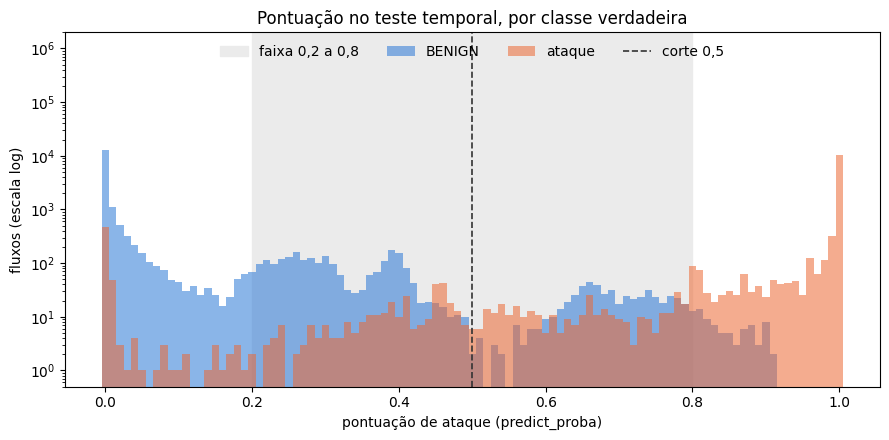

In [7]:
p_te = rf.predict_proba(X_te)[:, 1]

# com 100 árvores a pontuação anda em passos de 0,01: um bin por valor possível
bins = np.linspace(-0.005, 1.005, 102)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvspan(0.2, 0.8, color='0.92', zorder=0, label='faixa 0,2 a 0,8')
for classe, nome, cor in [(0, 'BENIGN', COR_BENIGN), (1, 'ataque', COR_ATAQUE)]:
    ax.hist(p_te[y_te.values == classe], bins=bins, histtype='stepfilled',
            alpha=0.55, color=cor, label=nome)
ax.axvline(0.5, color='0.2', linestyle='--', linewidth=1.2, label='corte 0,5')
ax.set_yscale('log')
ax.set_ylim(0.5, 2e6)
ax.set_xlabel('pontuação de ataque (predict_proba)')
ax.set_ylabel('fluxos (escala log)')
ax.set_title('Pontuação no teste temporal, por classe verdadeira')
ax.legend(loc='upper center', ncol=4, frameon=False)
plt.tight_layout()
plt.show()

In [8]:
faixas = {'p < 0,2': p_te < 0.2,
          '0,2 <= p <= 0,8': (p_te >= 0.2) & (p_te <= 0.8),
          'p > 0,8': p_te > 0.8,
          '0,45 <= p <= 0,55': (p_te >= 0.45) & (p_te <= 0.55)}
eh_ataque = y_te.values == 1
pd.DataFrame({nome: [(m & ~eh_ataque).sum(), (m & eh_ataque).sum(), m.sum()]
              for nome, m in faixas.items()},
             index=['BENIGN', 'ataque', 'total'])

,"p < 0,2","0,2 <= p <= 0,8","p > 0,8","0,45 <= p <= 0,55"
BENIGN,15963,2825,69,75
ataque,550,723,11411,186
total,16513,3548,11480,261


### Pergunta B.1

Os fluxos em que o modelo tem dúvida estão entre 0,2 e 0,8: são 3.548 fluxos, cerca de 11% do teste, sendo 2.825 benignos e 723 ataques. A maior parte do teste fica nos extremos, com 16.513 fluxos abaixo de 0,2 e 11.480 acima de 0,8. Mesmo em escala log, porém, a faixa do meio está longe de vazia. O tráfego benigno duvidoso forma um volume de algumas centenas de fluxos por valor de pontuação entre 0,2 e 0,45 e um segundo volume, de algumas dezenas, entre 0,55 e 0,8, enquanto os ataques se espalham por toda a faixa.

O corte 0,5 passa por uma região povoada. Ele cai num vale entre os dois volumes, mas ainda há 261 fluxos entre 0,45 e 0,55 (75 benignos e 186 ataques), de modo que qualquer deslocamento do limiar move dezenas de fluxos de um lado para o outro da matriz de confusão. O histograma também mostra 550 ataques com pontuação abaixo de 0,2, erros cometidos com convicção que nenhum ajuste fino em torno de 0,5 recupera.

---

## c) ROC contra Precision-Recall

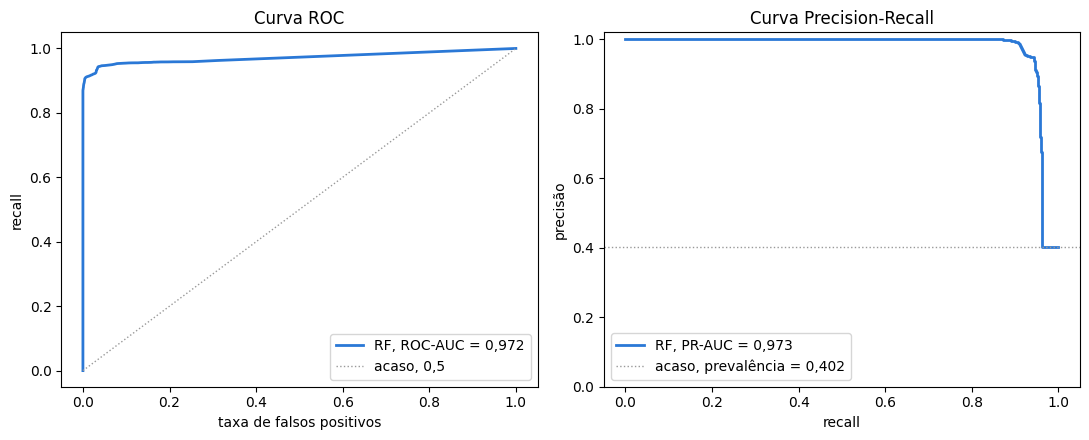

ROC-AUC 0.9721 | PR-AUC 0.9731 | prevalência de ataque no teste 0.4021


In [9]:
roc_auc = roc_auc_score(y_te, p_te)
pr_auc = average_precision_score(y_te, p_te)
prevalencia = y_te.mean()
fpr, tpr, _ = roc_curve(y_te, p_te)
precisao, revocacao, _ = precision_recall_curve(y_te, p_te)
br = lambda x: f'{x:.3f}'.replace('.', ',')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.plot(fpr, tpr, color=COR_BENIGN, linewidth=2, label=f'RF, ROC-AUC = {br(roc_auc)}')
ax1.plot([0, 1], [0, 1], color='0.6', linestyle=':', linewidth=1, label='acaso, 0,5')
ax1.set_xlabel('taxa de falsos positivos')
ax1.set_ylabel('recall')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')

ax2.step(revocacao, precisao, where='post', color=COR_BENIGN, linewidth=2,
         label=f'RF, PR-AUC = {br(pr_auc)}')
ax2.axhline(prevalencia, color='0.6', linestyle=':', linewidth=1,
            label=f'acaso, prevalência = {br(prevalencia)}')
ax2.set_xlabel('recall')
ax2.set_ylabel('precisão')
ax2.set_ylim(0, 1.02)
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc='lower left')
plt.tight_layout()
plt.show()

print(f'ROC-AUC {roc_auc:.4f} | PR-AUC {pr_auc:.4f} | prevalência de ataque no teste {prevalencia:.4f}')

In [10]:
pred05 = (p_te >= 0.5).astype(int)
eh_bot = (label_te == CLASSE_DIFICIL).values

display(pd.DataFrame({'fluxos': [int(y_te.sum()), int(eh_bot.sum())],
                      'recall no corte 0,5': [recall_score(y_te, pred05), pred05[eh_bot].mean()]},
                     index=['ataque (global)', CLASSE_DIFICIL]).round(4))

print(f'{CLASSE_DIFICIL} com pontuação 0: {(p_te[eh_bot] == 0).mean():.1%}')
print(f'recall de {CLASSE_DIFICIL} mesmo no corte 0,05: {(p_te[eh_bot] >= 0.05).mean():.4f}')

,fluxos,"recall no corte 0,5"
ataque (global),12684,0.9332
Bot,592,0.1554


Bot com pontuação 0: 75.8%
recall de Bot mesmo no corte 0,05: 0.1605


### Pergunta C.1

Neste teste as duas áreas contam a mesma história: ROC-AUC de 0,972 e PR-AUC de 0,973. Isso acontece porque aqui o ataque não é uma classe rara, já que 40,2% do teste é ataque, e a curva ROC só esconde falsos positivos quando os negativos são muito mais numerosos que os positivos. As referências de acaso, no entanto, são diferentes: 0,5 para a ROC e 0,402 para a PR. As duas curvas mostram também o mesmo defeito: a precisão se mantém perto de 1 até um recall próximo de 0,9, e os últimos ataques só são alcançados quando a precisão desaba para o nível do acaso, porque esses ataques recebem pontuação 0.

Para a reunião com o gestor do SOC eu levaria a PR-AUC. A precisão tem o número de alertas no denominador e responde diretamente à pergunta do analista sobre quantos dos alertas da fila valem a pena. Além disso, em produção a proporção de ataques será muito menor que os 40% deste recorte, e nessa situação a ROC continuaria parecendo excelente enquanto a precisão caísse, que é a falácia da taxa-base.

### Pergunta C.2

Não é compatível. No corte 0,5 o recall global é 0,933, mas o recall do Bot é apenas 0,155: dos 592 fluxos de Bot no teste, a grande maioria passa sem alerta. O número global é dominado pelas classes volumosas e fáceis, e os 592 fluxos de Bot são menos de 5% dos 12.684 ataques do teste, pouco para mover a média.

Isso mostra que um único limiar para todas as classes esconde as classes difíceis. No caso do Bot, o limiar nem é a alavanca certa: 75,8% dos fluxos recebem pontuação 0, e mesmo com o corte em 0,05 o recall sobe só para 0,161, enquanto o volume de alertas falsos cresceria para todo o tráfego. O problema está na mudança de comportamento da campanha observada no Roteiro 2, não no ponto de corte. Por isso o desempenho precisa ser acompanhado por classe, e classes como o Bot pedem tratamento próprio, com features ou modelos específicos, em vez de um ajuste do limiar global.